# Loan Default Prediction — Model Training

This notebook trains and compares machine learning models for predicting loan default.

The prepared dataset from the feature engineering stage is used to:
- Establish a baseline
- Train classification models
- Evaluate model performance
- Compare different algorithms
- Select a suitable model for further evaluation and deployment

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [10]:
import joblib

preprocessor = joblib.load("preprocessor.pkl")

X_train_processed = joblib.load("X_train_processed.pkl")
X_test_processed = joblib.load("X_test_processed.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

In [11]:
X_train_processed.shape, X_test_processed.shape

((204277, 33), (51070, 33))

In [12]:
y_train.shape, y_test.shape

((204277,), (51070,))

In [5]:
y_train.value_counts()

Default
0    180555
1     23722
Name: count, dtype: int64

In [6]:
## Step 1  — Logistic Regression : classification algorithm
# Our problem is: Given a borrower's information, predict whether the loan will default.

In [8]:
#1 Train our first model LOgistic Regression 

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [9]:
logistic_model.fit(
    X_train_processed,
    y_train
)

E:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [13]:
# error fixed 
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [14]:
y_pred = logistic_model.predict(X_test_processed)

In [15]:
y_prob = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [16]:
# The model predicted no default for the first 20 test loans.
# only about 11.6% of loans actually default, so most predictions will naturally be 0.

y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [17]:
# By default, Logistic Regression uses a threshold of 0.5:
# Probability >= 0.50 → 1
# Probability <  0.50 → 0

y_prob[:10]

array([0.03008797, 0.0202304 , 0.07543752, 0.15185037, 0.08413518,
       0.0095199 , 0.35644877, 0.07222038, 0.33723884, 0.1574026 ])

In [18]:
# Evaluate Logistic Regression

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.8852946935578617
Precision: 0.6102719033232629
Recall   : 0.03405833754847412
F1 Score : 0.06451612903225806
ROC-AUC  : 0.7531006502408647


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070



In [20]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[45010,   129],
       [ 5729,   202]])

In [ ]:
# insughts 
#  45,010 → correctly identified non-defaults
#  129 → incorrectly flagged as defaults
#  5,729 → actual defaulters that the model missed ❌
#  202 → correctly identified defaulters

# This is the key problem

# There were: 5931 actual defaulters but the model caught only: 202

# That's why: Recall = 202 / (202 + 5729) ≈ 3.41%

# So the model is missing most of the risky borrowers.

In [ ]:
# we should investigate whether changing the classification threshold improves our ability to catch defaulters
# More borrowers classified as potential defaulters
        # Higher Recall
        # But potentially lower Precision

In [21]:
# model 2.  Decision Tree.

from sklearn.tree import DecisionTreeClassifier

In [22]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    class_weight="balanced"
)

## class_weight="balanced"?  class_weight="balanced" tells the model to give more
# importance to the minority class (Default = 1) during training.
## And max_depth=10 prevents the tree from becoming unnecessarily deep and memorizing the training data.

In [23]:
# Train decision tree
decision_tree.fit(
    X_train_processed,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [24]:
dt_pred = decision_tree.predict(
    X_test_processed
)

In [25]:
dt_prob = decision_tree.predict_proba(
    X_test_processed
)[:, 1]

In [26]:
# Evaluate Decision Tree

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_prob)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_roc_auc)

Accuracy : 0.6614646563540238
Precision: 0.20263901979264845
Recall   : 0.6525037936267072
F1 Score : 0.3092412801150665
ROC-AUC  : 0.7063374624437484


In [27]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.94      0.66      0.78     45139
           1       0.20      0.65      0.31      5931

    accuracy                           0.66     51070
   macro avg       0.57      0.66      0.54     51070
weighted avg       0.85      0.66      0.72     51070



In [28]:
dt_cm = confusion_matrix(y_test, dt_pred)
dt_cm

array([[29911, 15228],
       [ 2061,  3870]])

In [ ]:
## Insights
# The Decision Tree caught: 3,870 / 5,931  actual defaulters.

# 29,911 → correctly identified non-defaults
# 15,228 → non-defaults incorrectly flagged as defaults
# 2,061 → actual defaulters missed
# 3,870 → actual defaulters correctly detected

In [ ]:
# Recall ↑ dramatically but: Precision ↓
# It is saying "potential default" for many borrowers who ultimately don't default.

# That's reflected in: Precision = 20.26%
## For loan default prediction, recall is important because missing a genuine defaulter can be costly.

In [29]:
## Model 3 : Random Forest
# Random Forest combines many decision trees and often performs better than a single tree.
# We'll use class balancing again

from sklearn.ensemble import RandomForestClassifier

In [30]:
random_forest = RandomForestClassifier(
    n_estimators=200,  # build 200 trees
    max_depth=12,      # control tree complexity
    class_weight="balanced", # account for the imbalanced target
    random_state=42,    # reproducible results
    n_jobs=-1           # use available CPU cores to train faster
)

In [31]:
random_forest.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [32]:
rf_pred = random_forest.predict(
    X_test_processed
)

In [33]:
rf_prob = random_forest.predict_proba(
    X_test_processed
)[:, 1]

In [34]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Accuracy : 0.7816917955747014
Precision: 0.273169883498522
Recall   : 0.5297588939470579
F1 Score : 0.36046578328457524
ROC-AUC  : 0.752970872575025


In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87     45139
           1       0.27      0.53      0.36      5931

    accuracy                           0.78     51070
   macro avg       0.60      0.67      0.61     51070
weighted avg       0.85      0.78      0.81     51070



In [36]:
rf_cm = confusion_matrix(y_test, rf_pred)
rf_cm

array([[36779,  8360],
       [ 2789,  3142]])

In [37]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.885295,0.610272,0.034058,0.064516,0.753101
1,Decision Tree,0.661465,0.202639,0.652504,0.309241,0.706337
2,Random Forest,0.781692,0.273170,0.529759,0.360466,0.752971


In [ ]:
# Logistic Regression

Highest accuracy and precision.
But 3.41% recall is extremely poor.
It misses most actual defaulters.

Decision Tree

Best recall: 65.25%.
But ROC-AUC is lower and precision is only 20.26%.
It catches many defaulters but produces many false alarms.

🏆 Random Forest

Recall: 52.98%, much better than Logistic Regression.
F1: 36.05%, the best of the three.
ROC-AUC: 75.30%, essentially the same as Logistic Regression.
It gives a better balance between catching defaults and avoiding excessive false positives.

In [38]:
# to understand which features are driving the Random Forest's predictions.
random_forest.feature_importances_

array([0.20712724, 0.13167727, 0.09546635, 0.05530353, 0.09873957,
       0.01635859, 0.15604125, 0.01673071, 0.04488539, 0.01892671,
       0.0268227 , 0.00513701, 0.00625727, 0.00533715, 0.00594514,
       0.00977753, 0.00430182, 0.00461303, 0.00707279, 0.00591623,
       0.00675737, 0.00521558, 0.00552716, 0.00556435, 0.00683713,
       0.00689636, 0.00494128, 0.00529753, 0.00485707, 0.00633393,
       0.00482175, 0.00741489, 0.00709833])

In [41]:
feature_names = preprocessor.get_feature_names_out()
len(feature_names)

33

In [42]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,num__Age,0.207127
6,num__InterestRate,0.156041
1,num__Income,0.131677
4,num__MonthsEmployed,0.098740
2,num__LoanAmount,0.095466
3,num__CreditScore,0.055304
8,num__DTIRatio,0.044885
10,num__LoanMonth,0.026823
9,num__LoanYear,0.018927
7,num__LoanTerm,0.016731


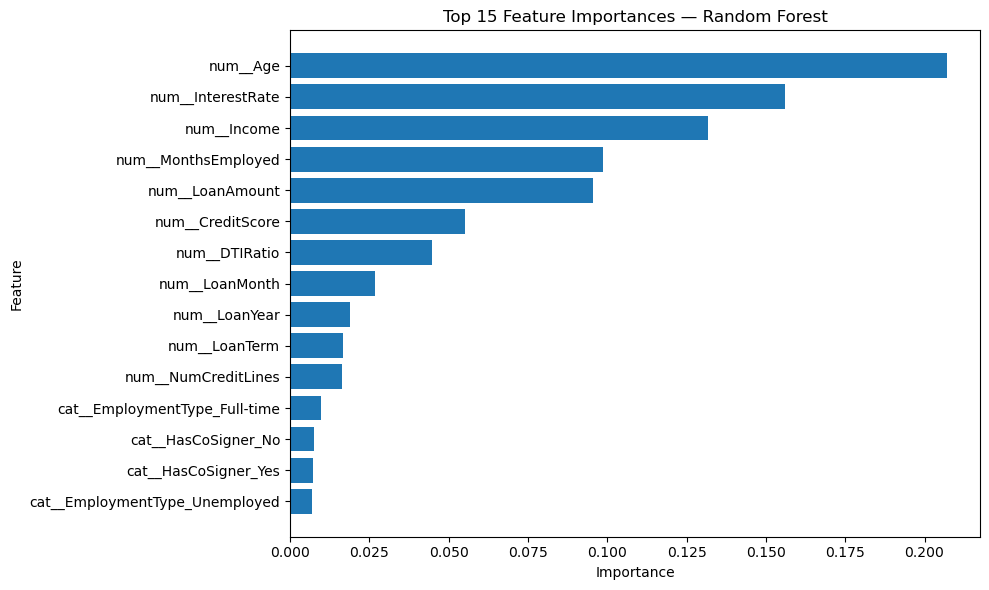

In [43]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

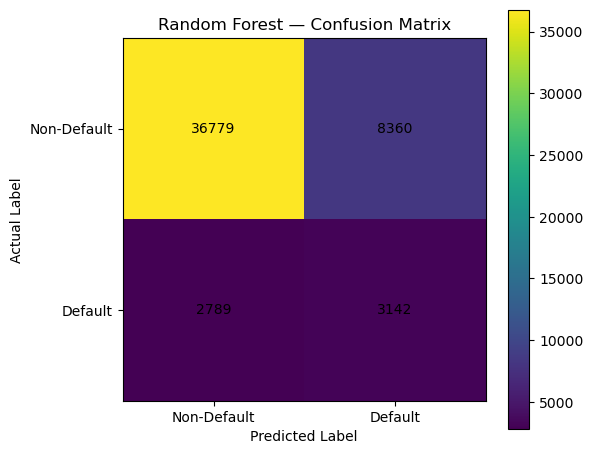

In [44]:
## Confusion Matrix Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(rf_cm)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-Default", "Default"])
plt.yticks([0, 1], ["Non-Default", "Default"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            rf_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [45]:
# 255,347 rows ≈ 2.55 lakh But we split it into:
# Training → 204,277
# Testing → 51,070
# TN + FP + FN + TP = total testing value

## So we're going to investigate whether a different threshold can improve the balance between:
# catching more defaulters ↔ avoiding too many false alarms.
# That's called threshold tuning 

In [ ]:
# Yes. We finished the model comparison and feature importance. Now we'll do threshold tuning for the Random Forest.
# This is important because our current Random Forest uses the default threshold of 0.50, giving:
# Recall: 52.98%
# Precision: 27.32%
# F1: 36.05%

In [46]:
rf_prob

array([0.22200187, 0.17905548, 0.31191726, ..., 0.32226893, 0.34008814,
       0.31211702])

In [47]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

In [48]:
threshold_results = []

for threshold in thresholds:
    
    threshold_pred = (rf_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_pred),
        "Recall": recall_score(y_test, threshold_pred),
        "F1 Score": f1_score(y_test, threshold_pred)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.20,0.127759,0.981791,0.226096
1,0.25,0.140930,0.951104,0.245485
2,0.30,0.157387,0.896982,0.267787
3,0.35,0.180676,0.833923,0.297004
4,0.40,0.207208,0.749283,0.324640
5,0.45,0.238577,0.647951,0.348745
6,0.50,0.273170,0.529759,0.360466


In [49]:
#  Find the best F1 threshold
best_threshold = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold

Threshold    0.500000
Precision    0.273170
Recall       0.529759
F1 Score     0.360466
Name: 6, dtype: float64

In [ ]:
# Insights
# For the thresholds we tested, 0.50 is actually the best threshold according to F1.
# So we do not need to change the threshold.

In [50]:
# Create the final Random Forest prediction
final_threshold = 0.50

final_pred = (rf_prob >= final_threshold).astype(int)

In [51]:
np.array_equal(final_pred, rf_pred)

True

In [52]:
final_cm = confusion_matrix(y_test, final_pred)

final_cm

array([[36779,  8360],
       [ 2789,  3142]])

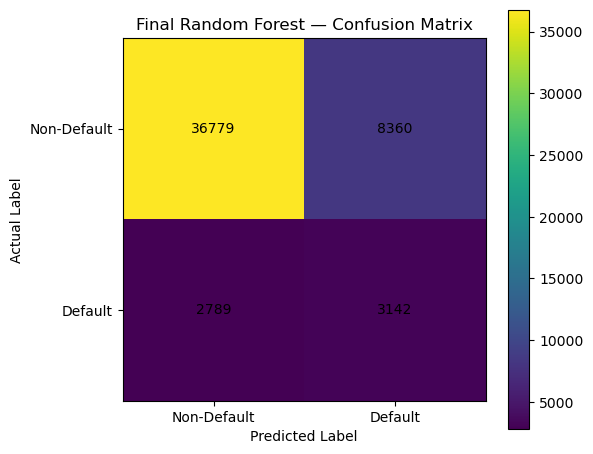

In [53]:
plt.figure(figsize=(6, 5))

plt.imshow(final_cm)

plt.title("Final Random Forest — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-Default", "Default"])
plt.yticks([0, 1], ["Non-Default", "Default"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            final_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# Among the three models we trained, Random Forest currently provides the best F1-score and a much better recall/precision balance than Logistic Regression.

In [54]:
# Save the final model :Random Forest
joblib.dump(
    random_forest,
    "random_forest_model.pkl"
)

['random_forest_model.pkl']

In [55]:
# save the selected threshold:
joblib.dump(
    final_threshold,
    "decision_threshold.pkl"
)

['decision_threshold.pkl']

In [56]:
# Final Model Metrics

final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_roc_auc = roc_auc_score(y_test, rf_prob)

print("Final Random Forest Performance")
print("--------------------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_roc_auc)

Final Random Forest Performance
--------------------------------
Accuracy : 0.7816917955747014
Precision: 0.273169883498522
Recall   : 0.5297588939470579
F1 Score : 0.36046578328457524
ROC-AUC  : 0.752970872575025


In [57]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87     45139
           1       0.27      0.53      0.36      5931

    accuracy                           0.78     51070
   macro avg       0.60      0.67      0.61     51070
weighted avg       0.85      0.78      0.81     51070



In [58]:
# ROC Curve
from sklearn.metrics import roc_curve

In [59]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_prob
)

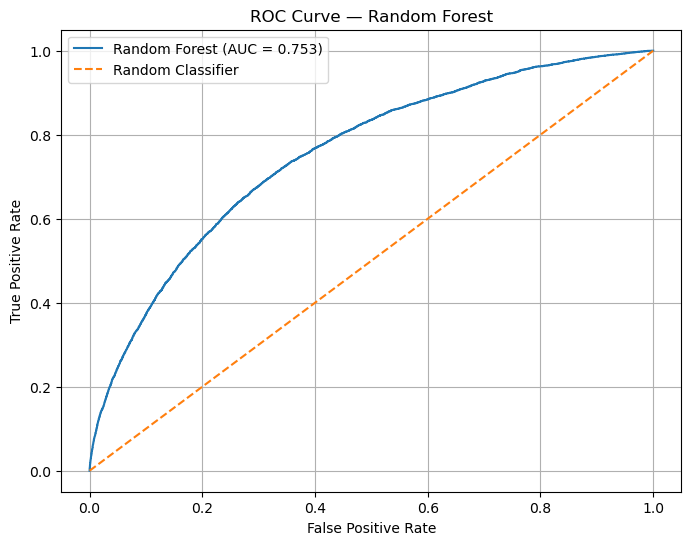

In [60]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {final_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.grid()
plt.show()

In [61]:
# Save the final evaluation results
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_results

,Metric,Score
0,Accuracy,0.781692
1,Precision,0.273170
2,Recall,0.529759
3,F1 Score,0.360466
4,ROC-AUC,0.752971


In [ ]:
# The most important result is the Default = 1 class:

# Recall = 52.98% → the model catches about half of the actual defaulters.
# Precision = 27.32% → among borrowers predicted as defaulters, about 27% actually default.
# F1 = 36.05% → this is the best F1 among the three models we tested.
# ROC-AUC = 75.30% → the model has meaningful ability to distinguish defaulters from non-defaulters.